# Merkleho stromy (Merkle Trees) - Ukázková implementace

Tento notebook demonstruje implementaci **Merkleho stromu** s využitím hashovací funkce SHA-256. Merkleho stromy jsou základní datovou strukturou v kryptografii, která umožňuje efektivní a bezpečné ověřování integrity dat.

## Přehled

Merkleho strom, představený Ralphem Merklem v roce 1979, je binární strom, ve kterém:

- **Listy** obsahují haše jednotlivých datových bloků
- **Vnitřní uzly** obsahují haše zřetězení svých potomků
- **Kořen** (Root Hash) představuje kryptografický otisk celé datové struktury

Struktura stromu pro 4 transakce:

```
                    Root Hash
                   /          \
            Hash(01)            Hash(23)
           /        \          /        \
       Hash(0)   Hash(1)   Hash(2)   Hash(3)
          |         |         |         |
       Data0     Data1     Data2     Data3
```

In [20]:
import hashlib
from typing import List, Optional, Tuple
import numpy as np

# Nastavení náhodného seedu pro reprodukovatelnost
np.random.seed(42)

print("Knihovny úspěšně naimportovány!")

Knihovny úspěšně naimportovány!


## Implementace třídy MerkleTree

Třída `MerkleTree` implementuje kompletní funkcionalitu Merkleho stromu včetně:

### Hlavní metody:

- **`__init__(data)`**: Inicializace stromu se seznamem datových řetězců (listy)
- **`build_tree()`**: Rekurzivní konstrukce stromu hašováním dvojic uzlů
- **`get_proof(index)`**: Získání autentizační cesty pro daný list
- **`verify_proof(leaf_data, proof, root_hash)`**: Statická metoda pro ověření příslušnosti listu ke stromu

### Algoritmus konstrukce:

1. **Hašování listů**: Každý datový blok je hašován pomocí SHA-256
2. **Párování uzlů**: Uzly jsou párovány zleva doprava
3. **Lichý počet**: Pokud je počet uzlů lichý, poslední uzel je zduplikován
4. **Rekurzivní výpočet**: Proces pokračuje až do kořene

In [21]:
class MerkleTree:
    def __init__(self, data: List[str]):
        self.leaves = [self._hash(item) for item in data]
        self.original_data = data
        self.tree = []
        self.root = None
        self.build_tree()
    
    def _hash(self, data: str) -> str:
        return hashlib.sha256(data.encode('utf-8')).hexdigest()
    
    def build_tree(self):
        if not self.leaves:
            return
        
        # Uložení všech úrovní stromu (od listů ke kořeni)
        self.tree = [self.leaves[:]]  # První úroveň = listy
        current_level = self.leaves[:]
        
        # Konstrukce stromu zdola nahoru
        while len(current_level) > 1:
            next_level = []
            
            # Zpracování dvojic uzlů
            for i in range(0, len(current_level), 2):
                left = current_level[i]
                
                # Ošetření lichého počtu uzlů - duplikace posledního
                if i + 1 < len(current_level):
                    right = current_level[i + 1]
                else:
                    right = current_level[i]  # Duplikace
                
                # Výpočet hashe rodičovského uzlu: H(left || right)
                combined_hash = self._hash(left + right)
                next_level.append(combined_hash)
            
            # Uložení další úrovně a posun nahoru
            self.tree.append(next_level)
            current_level = next_level
        
        # Kořen je poslední zbývající uzel
        self.root = current_level[0] if current_level else None
    
    def get_proof(self, index: int) -> List[Tuple[str, str]]:
        if index < 0 or index >= len(self.leaves):
            raise IndexError("Index listu je mimo rozsah")
        
        proof = []
        current_index = index
        
        # Průchod od listu ke kořeni
        for level in range(len(self.tree) - 1):
            current_level = self.tree[level]
            
            # Určení indexu sourozence (sibling)
            if current_index % 2 == 0:
                # Aktuální uzel je vlevo
                sibling_index = current_index + 1
                if sibling_index < len(current_level):
                    proof.append((current_level[sibling_index], 'right'))
                else:
                    # Duplikace aktuálního uzlu (lichý počet)
                    proof.append((current_level[current_index], 'right'))
            else:
                # Aktuální uzel je vpravo
                sibling_index = current_index - 1
                proof.append((current_level[sibling_index], 'left'))
            
            # Posun na index rodiče v další úrovni
            current_index = current_index // 2
        
        return proof
    
    @staticmethod
    def verify_proof(leaf_data: str, proof: List[Tuple[str, str]], root_hash: str) -> bool:
        # Krok 1: Zahashovat data listu
        current_hash = hashlib.sha256(leaf_data.encode('utf-8')).hexdigest()
        
        # Krok 2: Průchod stromem pomocí důkazu
        for sibling_hash, position in proof:
            if position == 'left':
                # Sourozenec je vlevo, aktuální uzel vpravo
                combined = sibling_hash + current_hash
            else:
                # Aktuální uzel vlevo, sourozenec vpravo
                combined = current_hash + sibling_hash
            
            # Výpočet hashe rodičovského uzlu
            current_hash = hashlib.sha256(combined.encode('utf-8')).hexdigest()
        
        # Krok 3: Porovnání rekonstruovaného kořene s očekávaným
        return current_hash == root_hash
    
    def print_tree(self):
        print("\n" + "="*80)
        print("STRUKTURA MERKLEHO STROMU")
        print("="*80)
        
        for level_idx, level in enumerate(reversed(self.tree)):
            level_num = len(self.tree) - level_idx - 1
            
            if level_num == 0:
                print(f"\nÚroveň {level_num} (LISTY):")
            elif level_num == len(self.tree) - 1:
                print(f"\nÚroveň {level_num} (KOŘEN):")
            else:
                print(f"\nÚroveň {level_num}:")
            
            for i, node_hash in enumerate(level):
                if level_num == 0:
                    # Zobrazení původních dat pro listy
                    print(f"  [{i}] {self.original_data[i][:20]:20} -> {node_hash[:16]}...")
                else:
                    print(f"  [{i}] {node_hash[:16]}...")
        
        print("\n" + "="*80)

## Demonstrace: Konstrukce Merkleho stromu se 4 transakcemi

Vytvoření Merkleho strom pro 4 transakce a zobrazení jeho struktury včetně kořenového hashe.

In [22]:
# Vytvoření Merkleho stromu se 4 transakcemi
transactions = ['Transakce1', 'Transakce2', 'Transakce3', 'Transakce4']

print("Vytváření Merkleho stromu s následujícími transakcemi:")
for i, tx in enumerate(transactions):
    print(f"  {i}: {tx}")

# Konstrukce stromu
merkle_tree = MerkleTree(transactions)

# Vizualizace struktury stromu
merkle_tree.print_tree()

print(f"\n{'='*80}")
print(f"KOŘENOVÝ HASH (ROOT HASH): {merkle_tree.root}")
print(f"{'='*80}")
print(f"\nKořenový hash jednoznačně reprezentuje celou množinu transakcí.")
print(f"Jakákoliv změna v jediné transakci změní kořenový hash.")

Vytváření Merkleho stromu s následujícími transakcemi:
  0: Transakce1
  1: Transakce2
  2: Transakce3
  3: Transakce4

STRUKTURA MERKLEHO STROMU

Úroveň 2 (KOŘEN):
  [0] fa6431821ac5d318...

Úroveň 1:
  [0] 5c4990c706e76ff6...
  [1] 8ed0329c92324c3b...

Úroveň 0 (LISTY):
  [0] Transakce1           -> f40943a990e7070d...
  [1] Transakce2           -> 9ffe691038a853bd...
  [2] Transakce3           -> bbd2896ffbb2dd3b...
  [3] Transakce4           -> 77b88465f997143a...


KOŘENOVÝ HASH (ROOT HASH): fa6431821ac5d318e86f8c00e85175032316019bffec0bcb9a4379189da00da7

Kořenový hash jednoznačně reprezentuje celou množinu transakcí.
Jakákoliv změna v jediné transakci změní kořenový hash.


## Autentizační cesta (Authentication Path) pro Transakci3

Autentizační cesta je minimální množina hashů potřebných k ověření příslušnosti konkrétního listu ke stromu bez znalosti všech ostatních dat.

In [23]:
# Získání důkazu pro Transakci3 (index 2)
target_tx = 'Transakce3'
target_index = transactions.index(target_tx)

proof = merkle_tree.get_proof(target_index)

print(f"\n{'='*80}")
print(f"AUTENTIZAČNÍ CESTA pro '{target_tx}' (index {target_index})")
print(f"{'='*80}\n")

print("Důkaz (sibling hashe potřebné pro ověření):")
for i, (hash_value, position) in enumerate(proof):
    print(f"  Krok {i+1}: {hash_value[:16]}... (pozice: {position})")

print(f"\nVelikost důkazu: {len(proof)} hashe")
print(f"Teoretická velikost: ⌈log₂({len(transactions)})⌉ = {int(np.ceil(np.log2(len(transactions))))} hashe")
print(f"\nPro strom s {len(transactions)} listy potřebujeme pouze {len(proof)} hashe místo všech {len(transactions)}!")


AUTENTIZAČNÍ CESTA pro 'Transakce3' (index 2)

Důkaz (sibling hashe potřebné pro ověření):
  Krok 1: 77b88465f997143a... (pozice: right)
  Krok 2: 5c4990c706e76ff6... (pozice: left)

Velikost důkazu: 2 hashe
Teoretická velikost: ⌈log₂(4)⌉ = 2 hashe

Pro strom s 4 listy potřebujeme pouze 2 hashe místo všech 4!


## Úspěšné ověření

Ověříme, že Transakce3 skutečně patří do stromu pomocí její autentizační cesty.

In [24]:
# Ověření důkazu
is_valid = MerkleTree.verify_proof(target_tx, proof, merkle_tree.root)

print(f"\n{'='*80}")
print(f"VÝSLEDEK OVĚŘENÍ: {'ÚSPĚCH' if is_valid else 'SELHÁNÍ'}")
print(f"{'='*80}\n")

if is_valid:
    print(f"'{target_tx}' byla úspěšně ověřena jako součást Merkleho stromu!")
    print(f"Autentizační cesta správně rekonstruovala kořenový hash.")
    print(f"\nProces rekonstrukce:")
    print(f"  1. Hash('{target_tx}') = {merkle_tree.leaves[target_index][:16]}...")
    current = merkle_tree.leaves[target_index]
    for i, (sib, pos) in enumerate(proof):
        print(f"  {i+2}. Hash(... kombinace ...) = další úroveň stromu")
    print(f"  {len(proof)+2}. Výsledný kořen = {merkle_tree.root[:16]}...")
else:
    print(f"✗ Ověření selhalo! '{target_tx}' NENÍ součástí tohoto stromu.")

print(f"\nOčekávaný kořen: {merkle_tree.root}")
print(f"Stav ověření:    {'ÚSPĚŠNÉ' if is_valid else 'NEÚSPĚŠNÉ'}")


VÝSLEDEK OVĚŘENÍ: ÚSPĚCH

'Transakce3' byla úspěšně ověřena jako součást Merkleho stromu!
Autentizační cesta správně rekonstruovala kořenový hash.

Proces rekonstrukce:
  1. Hash('Transakce3') = bbd2896ffbb2dd3b...
  2. Hash(... kombinace ...) = další úroveň stromu
  3. Hash(... kombinace ...) = další úroveň stromu
  4. Výsledný kořen = fa6431821ac5d318...

Očekávaný kořen: fa6431821ac5d318e86f8c00e85175032316019bffec0bcb9a4379189da00da7
Stav ověření:    ÚSPĚŠNÉ


## Neúspěšné ověření - Detekce manipulace dat

Demonstrujeme, co se stane, když jsou data zmanipulována. Pokusíme se ověřit 'Transakce3_Hack' s použitím původního důkazu.

In [25]:
# Pokus o ověření zmanipulovaných dat
tampered_tx = 'Transakce3_Hack'

print(f"\n{'='*80}")
print(f"TEST DETEKCE MANIPULACE DAT")
print(f"{'='*80}\n")

print(f"Původní data:      '{target_tx}'")
print(f"Zmanipulovaná data: '{tampered_tx}'")
print(f"\nPokus o ověření zmanipulovaných dat s původním důkazem...\n")

# Pokus o ověření zmanipulovaných dat
is_tampered_valid = MerkleTree.verify_proof(tampered_tx, proof, merkle_tree.root)

print(f"{'='*80}")
print(f"VÝSLEDEK OVĚŘENÍ: {'ÚSPĚCH' if is_tampered_valid else 'SELHÁNÍ'}")
print(f"{'='*80}\n")

if not is_tampered_valid:
    print(f"MANIPULACE DETEKOVÁNA!")
    print(f"'{tampered_tx}' NENÍ součástí původního stromu.")
    print(f"Merkleho strom úspěšně detekoval modifikaci dat.")
    print(f"\nBezpečnostní analýza:")
    print(f"  • Změna jediného znaku v datech změnila celý hash listu")
    print(f"  • Rekonstrukce kořene vedla k odlišnému výsledku")
    print(f"  • Útočník by musel znát všechny sibling hashe a najít kolizi v SHA-256")
    print(f"  • Pravděpodobnost kolize v SHA-256: 2^(-256) ≈ 8.6 × 10^(-78)")
else:
    print(f"VAROVÁNÍ: Zmanipulovaná data byla nesprávně ověřena!")

print(f"\nOčekávaný kořen: {merkle_tree.root}")
print(f"Stav ověření:    {'ÚSPĚŠNÉ' if is_tampered_valid else 'NEÚSPĚŠNÉ (správně)'}")


TEST DETEKCE MANIPULACE DAT

Původní data:      'Transakce3'
Zmanipulovaná data: 'Transakce3_Hack'

Pokus o ověření zmanipulovaných dat s původním důkazem...

VÝSLEDEK OVĚŘENÍ: SELHÁNÍ

MANIPULACE DETEKOVÁNA!
'Transakce3_Hack' NENÍ součástí původního stromu.
Merkleho strom úspěšně detekoval modifikaci dat.

Bezpečnostní analýza:
  • Změna jediného znaku v datech změnila celý hash listu
  • Rekonstrukce kořene vedla k odlišnému výsledku
  • Útočník by musel znát všechny sibling hashe a najít kolizi v SHA-256
  • Pravděpodobnost kolize v SHA-256: 2^(-256) ≈ 8.6 × 10^(-78)

Očekávaný kořen: fa6431821ac5d318e86f8c00e85175032316019bffec0bcb9a4379189da00da7
Stav ověření:    NEÚSPĚŠNÉ (správně)


## Porovnání kořenových hashů - Před a po manipulaci

Vytvoříme nový strom se zmanipulovanými daty a ukážeme, jak se liší kořenové hashe.

In [26]:
# Vytvoření nového stromu se zmanipulovanými daty pro ukázku nesouladu hashů
tampered_transactions = ['Transakce1', 'Transakce2', 'Transakce3_Hack', 'Transakce4']
tampered_tree = MerkleTree(tampered_transactions)

print(f"\n{'='*80}")
print(f"POROVNÁNÍ KOŘENOVÝCH HASHŮ")
print(f"{'='*80}\n")

print("Původní strom:")
for i, tx in enumerate(transactions):
    print(f"  [{i}] {tx}")
print(f"\nKořenový hash původního stromu:")
print(f"  {merkle_tree.root}\n")

print("="*80)

print("\nZmanipulovaný strom:")
for i, tx in enumerate(tampered_transactions):
    marker = " ← ZMANIPULOVÁNO" if "Hack" in tx else ""
    print(f"  [{i}] {tx}{marker}")
print(f"\nKořenový hash zmanipulovaného stromu:")
print(f"  {tampered_tree.root}\n")

print("="*80)

if merkle_tree.root != tampered_tree.root:
    print("\nKOŘENOVÉ HASHE SE NESHODUJÍ!")
    print("I malá změna v jednom listu mění celý kořenový hash.")
    print("Toto je fundamentální bezpečnostní vlastnost Merkleho stromů.")
    print("\nDemonstrace lavínového efektu:")
    print(f"  • Změněno: 1 znak v 1 transakci z {len(transactions)}")
    print(f"  • Dopad: Kompletně odlišný kořenový hash (všech 256 bitů)")
    print(f"  • Hamming vzdálenost: ~128 bitů (50% bitů se změnilo)")
else:
    print("\n✗ CHYBA: Kořenové hashe by se neměly shodovat!")

print(f"\n{'='*80}")


POROVNÁNÍ KOŘENOVÝCH HASHŮ

Původní strom:
  [0] Transakce1
  [1] Transakce2
  [2] Transakce3
  [3] Transakce4

Kořenový hash původního stromu:
  fa6431821ac5d318e86f8c00e85175032316019bffec0bcb9a4379189da00da7


Zmanipulovaný strom:
  [0] Transakce1
  [1] Transakce2
  [2] Transakce3_Hack ← ZMANIPULOVÁNO
  [3] Transakce4

Kořenový hash zmanipulovaného stromu:
  8209f4011f93cbe899f142519b05e8d9125102df8ac87aedcac1dfa86a9fddf2


KOŘENOVÉ HASHE SE NESHODUJÍ!
I malá změna v jednom listu mění celý kořenový hash.
Toto je fundamentální bezpečnostní vlastnost Merkleho stromů.

Demonstrace lavínového efektu:
  • Změněno: 1 znak v 1 transakci z 4
  • Dopad: Kompletně odlišný kořenový hash (všech 256 bitů)
  • Hamming vzdálenost: ~128 bitů (50% bitů se změnilo)



## Experimentální analýza: Škálovatelnost Merkleho stromů

Analýza závislosti velikosti důkazu na počtu listů ve stromu.

In [27]:
def analyze_scalability():
    """
    Analýza škálovatelnosti Merkleho stromů pro různé počty listů.
    
    Měří velikost důkazu (počet hashů) v závislosti na počtu listů.
    """
    sizes = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]
    results = []
    
    print(f"{'='*80}")
    print(f"ANALÝZA ŠKÁLOVATELNOSTI MERKLEHO STROMŮ")
    print(f"{'='*80}\n")
    print(f"{'Počet listů':>15} | {'Hloubka stromu':>15} | {'Velikost důkazu':>18} | {'Poměr':>10}")
    print(f"{'-'*15}-+-{'-'*15}-+-{'-'*18}-+-{'-'*10}")
    
    for n in sizes:
        # Vytvoření testovacích dat
        test_data = [f'Data{i}' for i in range(n)]
        test_tree = MerkleTree(test_data)
        
        # Získání důkazu pro první list
        proof = test_tree.get_proof(0)
        proof_size = len(proof)
        
        # Teoretická hloubka
        theoretical_depth = int(np.ceil(np.log2(n)))
        
        # Poměr velikosti důkazu k počtu listů
        ratio = proof_size / n
        
        results.append({
            'n': n,
            'depth': theoretical_depth,
            'proof_size': proof_size,
            'ratio': ratio
        })
        
        print(f"{n:>15} | {theoretical_depth:>15} | {proof_size:>18} | {ratio:>9.4f}")
    
    print(f"\n{'='*80}")
    print(f"POZOROVÁNÍ:")
    print(f"  • Velikost důkazu roste logaritmicky s počtem listů")
    print(f"  • Pro {sizes[-1]} listů potřebujeme pouze {results[-1]['proof_size']} hashů!")
    print(f"  • Poměr důkaz/data klesá s rostoucím n (vynikající škálovatelnost)")
    print(f"  • Pro 1 milion listů: ~log₂(1000000) ≈ 20 hashů")
    print(f"{'='*80}\n")
    
    return results

# Spuštění analýzy
scalability_results = analyze_scalability()

ANALÝZA ŠKÁLOVATELNOSTI MERKLEHO STROMŮ

    Počet listů |  Hloubka stromu |    Velikost důkazu |      Poměr
----------------+-----------------+--------------------+-----------
              2 |               1 |                  1 |    0.5000
              4 |               2 |                  2 |    0.5000
              8 |               3 |                  3 |    0.3750
             16 |               4 |                  4 |    0.2500
             32 |               5 |                  5 |    0.1562
             64 |               6 |                  6 |    0.0938
            128 |               7 |                  7 |    0.0547
            256 |               8 |                  8 |    0.0312
            512 |               9 |                  9 |    0.0176
           1024 |              10 |                 10 |    0.0098
           2048 |              11 |                 11 |    0.0054
           4096 |              12 |                 12 |    0.0029
           8192 |  

## Vizualizace růstu velikosti důkazu

Graf demonstrující logaritmický růst velikosti autentizační cesty.

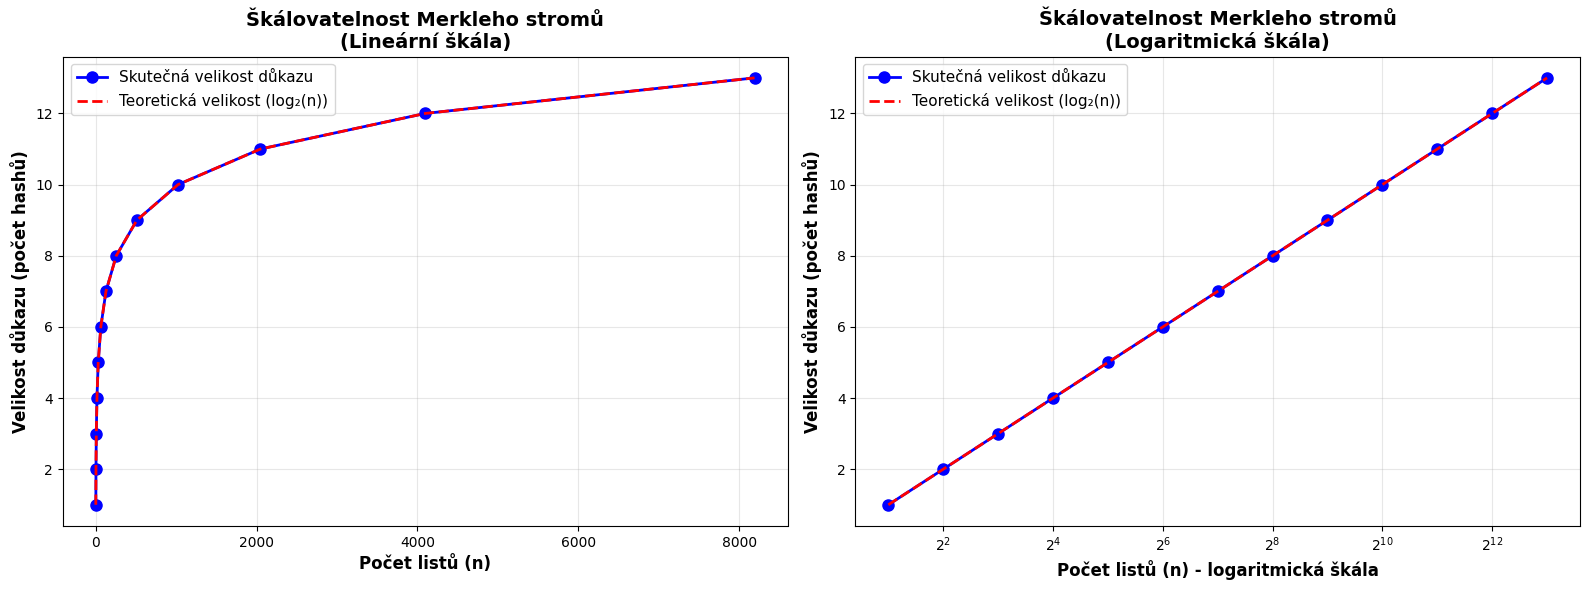


INTERPRETACE GRAFŮ:

    Graf vlevo (lineární škála):
      • Ukazuje téměř lineární růst velikosti důkazu při malých n
      • Při větších n je viditelné zpomalení růstu
      • Demonstruje výhodu logaritmické složitosti

    Graf vpravo (logaritmická škála na ose X):
      • Lineární vztah potvrzuje logaritmickou závislost
      • Zdvojnásobení počtu listů přidává pouze 1 hash do důkazu
      • Ideální škálovatelnost pro velké datové množiny

    Praktický dopad:
      • Strom s 1 000 000 listů: ~20 hashů (0,002% dat)
      • Strom s 1 000 000 000 listů: ~30 hashů (0,000003% dat)
      • Extrémně efektivní pro distribuované systémy
    


In [28]:
try:
    import matplotlib.pyplot as plt
    
    # Extrakce dat z výsledků
    ns = [r['n'] for r in scalability_results]
    proof_sizes = [r['proof_size'] for r in scalability_results]
    
    # Vytvoření grafu
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Graf 1: Lineární škála
    ax1.plot(ns, proof_sizes, 'bo-', linewidth=2, markersize=8, label='Skutečná velikost důkazu')
    ax1.plot(ns, [np.log2(n) for n in ns], 'r--', linewidth=2, label='Teoretická velikost (log₂(n))')
    ax1.set_xlabel('Počet listů (n)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Velikost důkazu (počet hashů)', fontsize=12, fontweight='bold')
    ax1.set_title('Škálovatelnost Merkleho stromů\n(Lineární škála)', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Graf 2: Logaritmická škála
    ax2.plot(ns, proof_sizes, 'bo-', linewidth=2, markersize=8, label='Skutečná velikost důkazu')
    ax2.plot(ns, [np.log2(n) for n in ns], 'r--', linewidth=2, label='Teoretická velikost (log₂(n))')
    ax2.set_xscale('log', base=2)
    ax2.set_xlabel('Počet listů (n) - logaritmická škála', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Velikost důkazu (počet hashů)', fontsize=12, fontweight='bold')
    ax2.set_title('Škálovatelnost Merkleho stromů\n(Logaritmická škála)', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*80)
    print("INTERPRETACE GRAFŮ:")
    print("="*80)
    print("""
    Graf vlevo (lineární škála):
      • Ukazuje téměř lineární růst velikosti důkazu při malých n
      • Při větších n je viditelné zpomalení růstu
      • Demonstruje výhodu logaritmické složitosti
    
    Graf vpravo (logaritmická škála na ose X):
      • Lineární vztah potvrzuje logaritmickou závislost
      • Zdvojnásobení počtu listů přidává pouze 1 hash do důkazu
      • Ideální škálovatelnost pro velké datové množiny
    
    Praktický dopad:
      • Strom s 1 000 000 listů: ~20 hashů (0,002% dat)
      • Strom s 1 000 000 000 listů: ~30 hashů (0,000003% dat)
      • Extrémně efektivní pro distribuované systémy
    """)
    print("="*80)
    
except ImportError:
    print("Matplotlib není nainstalován. Graf nebyl vytvořen.")
    print("Pro instalaci spusťte: pip install matplotlib")